# Análise em "Points"

### Leitura do Shape da área da cidade

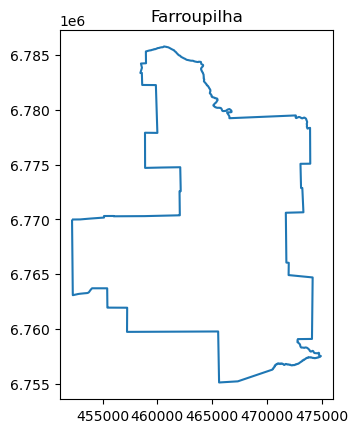

In [36]:
import geopandas
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point

gdf_farroupilha = geopandas.read_file('/home/jovyan/work/data/input/params/far/lim_munic/Limite_Municipal.shp')
gdf_farroupilha_urb = geopandas.read_file('/home/jovyan/work/data/input/params/far/perimetro_urb/Perimetro_Urbano.shp')

gdf_farroupilha.plot()

plt.title("Farroupilha")

plt.show()

### Leitura da tabela de Points

In [37]:
import os, sys
from pyspark.sql import SparkSession

sys.path.append(os.path.join(os.getcwd(), "/home/jovyan/work/src/pyspark_app"))

import session

spark = SparkSession.builder.getOrCreate()
url = session.jdbc_url()
props = session.jdbc_props()

table_name = "gps.points"

df = spark.read.jdbc(
    url=url,
    table=table_name,
    properties=props
)

df_points = df.toPandas()

<Axes: >

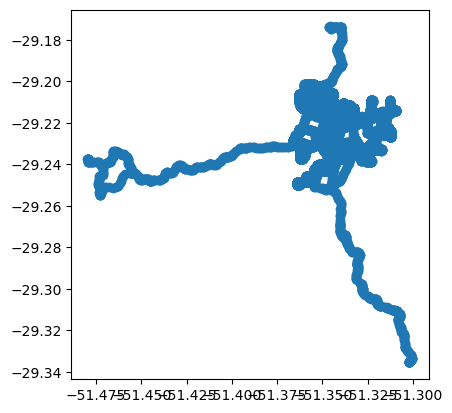

In [38]:
gdf_points = geopandas.GeoDataFrame(
    df_points, 
    geometry=df_points.apply(lambda row: Point(row['lon'], row['lat']), axis=1), 
    crs="EPSG:4326"
)

gdf_points.plot()

### Exibição e Validação dos Pontos dentro da Área

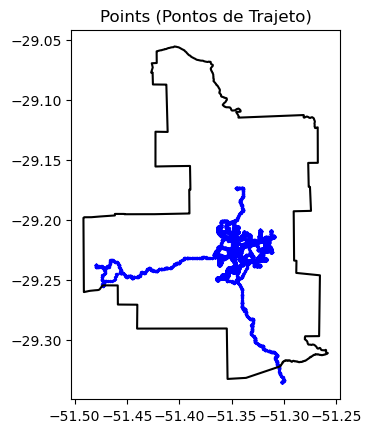

In [39]:
gdf_farroupilha = gdf_farroupilha.to_crs(gdf_points.crs)

ax = gdf_farroupilha.plot(color='black', edgecolor='black')
gdf_points.plot(ax=ax, color='blue', markersize=2)

plt.title("Points (Pontos de Trajeto)")

fig = ax.get_figure()
fig.savefig("/home/jovyan/work/data/output/imagem_points.png")

In [40]:
def point_in_polygon(x, y, poly_coords):
    num = len(poly_coords)
    j = num - 1
    inside = False
    for i in range(num):
        xi, yi = poly_coords[i]
        xj, yj = poly_coords[j]
        if ((yi > y) != (yj > y)) and \
           (x < (xj - xi) * (y - yi) / (yj - yi + 1e-14) + xi):
            inside = not inside
        j = i
    return inside

poly_geom = gdf_farroupilha.geometry.iloc[0]

polygon_coords = list(poly_geom.coords)

df_points['is_inside_area'] = df_points.apply(
    lambda row: point_in_polygon(row['lon'], row['lat'], polygon_coords), axis=1
)

df_points['is_inside_area'] =  df_points['is_inside_area'].astype(bool)

In [41]:
counts = df_points['is_inside_area'].value_counts(dropna=False)
print(counts)

is_inside_area
True     14883
False       67
Name: count, dtype: int64


### Gravação na base de dados

In [42]:
df_spark = spark.createDataFrame(df_points)

df_spark.write \
    .format("jdbc") \
    .option("url", url) \
    .option("dbtable", table_name) \
    .options(**props) \
    .mode("overwrite") \
    .save()